In [1]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [2]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [3]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = 37
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=45
proposed_test_number=1
report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'


num_of_cars=20
end_time_limit=100000
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/45_report_proposed_test_1.csv', 'local_only': '../results/reports/37_report_local_only_test.csv', 'offload_only': '../results/reports/37_report_offload_only_test.csv', 'random': '../results/reports/37_report_random_test.csv'}


In [4]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/45_report_proposed_test_1.csv
The time limit is: 100000
Header --->
   vehicle_id  task_id  execution_location      size    distance  \
0           1        1                   0   3000000  193.826094   
1           1        2                   0   9000000  193.816105   
2           1        3                   0  10000000  193.776149   
3           1        6                   0   7000000  193.515967   
4           1        8                   0   8000000  193.225819   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0            0.0        5000000000           1      5001             1   
1            0.0        5000000000        5001     10001           101   
2            0.0        5000000000       10001     15001           201   
3            0.0        7000000000       15001     22001           501   
4            0.0        6000000000       22001     28001           701   

   response_t

In [5]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time    45896.364486
              total_energy         0.773439
local_only    response_time    49828.353659
              total_energy         0.587500
offload_only  response_time    45612.500000
              total_energy         0.725532
random        response_time    46567.488770
              total_energy         0.811171
dtype: float64


In [6]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->


            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1            59680.857143        1146.071429     3892.857143   
2            51322.512821        3390.923077     3015.384615   
3            50652.105263        1240.000000     5473.684211   
4            35789.346667        2261.480000     2160.000000   
5            44711.444444          38.694444     2205.555556   
6            49710.041667         681.583333     2791.666667   
7            45742.905263        5920.073684     1955.789474   
8            33866.071429         408.880952     3033.333333   
9            48407.950000        2534.750000     2955.000000   
10           52946.415094        1125.150943     2494.339623   
11           50502.105263         812.157895     5136.842105   
12           46567.600000        1757.585714     2280.000000   
13           48874.054054         438.270270     3151.351351   
14           46501.393443        1375.54

In [7]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                 1671064              32090          109000   
2                 2001578             132246          117600   
3                  962390              23560          104000   
4                 2684201             169611          162000   
5                 3219224               2786          158800   
6                 2386082              32716          134000   
7                 4345576             562407          185800   
8                 1422375              17173          127400   
9                 1936318             101390          118200   
10                2806160              59633          132200   
11                 959540              15431           97600   
12                3259732             123031          159600   
13                1808340              16216          116600   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1313             1312.0              112.0          1200.0               0.0   
2001             2000.0                0.0          2000.0               0.2   
2113             2012.0               84.0           800.0               0.0   
2223             2122.0              122.0          2000.0               0.0   
2301             2000.0                0.0          2000.0               0.2   
...                 ...                ...             ...               ...   
99001           95200.0                0.0          8000.0               0.8   
99294           94293.0             3299.0           600.0               0.0   
99746           53045.0             2577.0          1400.0               0.0   
99836           94035.0             2143.0          1800.0               0.0   
99950     

local_only -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
2001        2000.000000                0.0     2000.000000          0.200000   
3001        3000.000000                0.0     3000.000000          0.300000   
4001        3975.000000                0.0     3500.000000          0.350000   
5001        5000.000000                0.0     5000.000000          0.500000   
6001        5966.666667                0.0     5333.333333          0.533333   
...                 ...                ...             ...               ...   
95001      93475.000000                0.0     5750.000000          0.575000   
96001      94400.000000                0.0     5500.000000          0.550000   
97001      95575.000000                0.0     5500.000000          0.550000   
98001      96450.000000                0.0     3500.000000          0.350000   
99001   

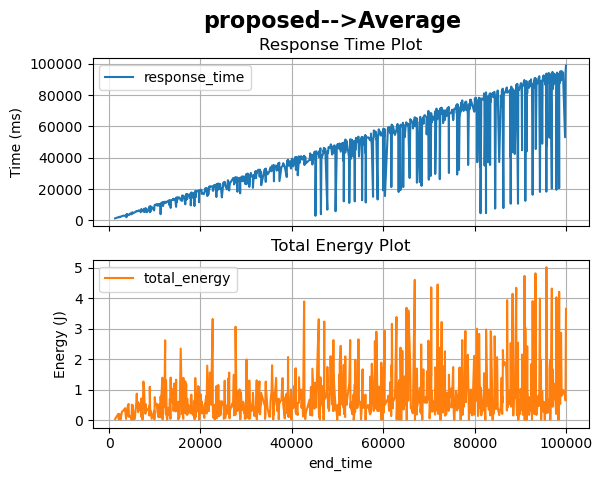

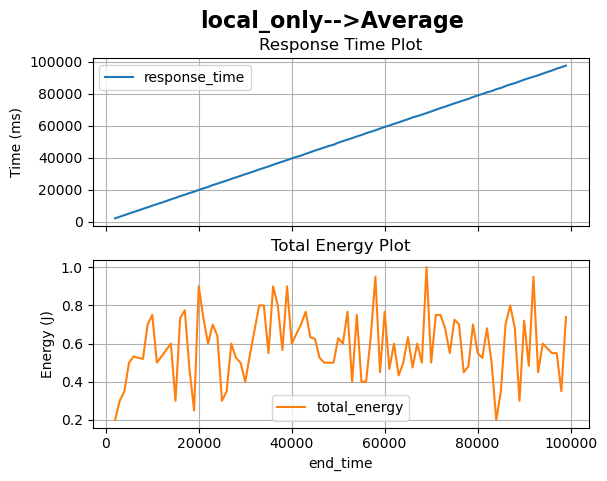

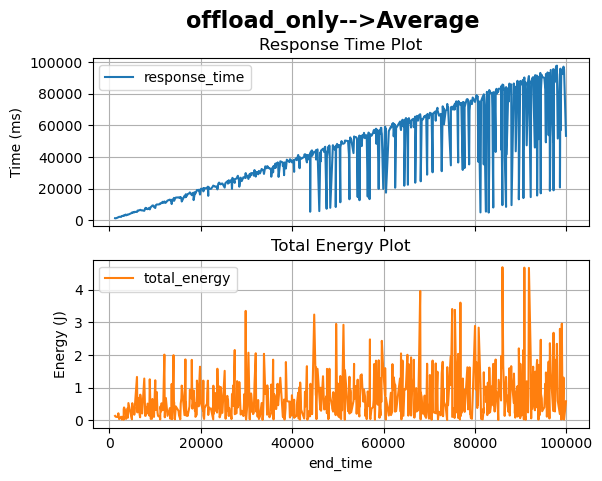

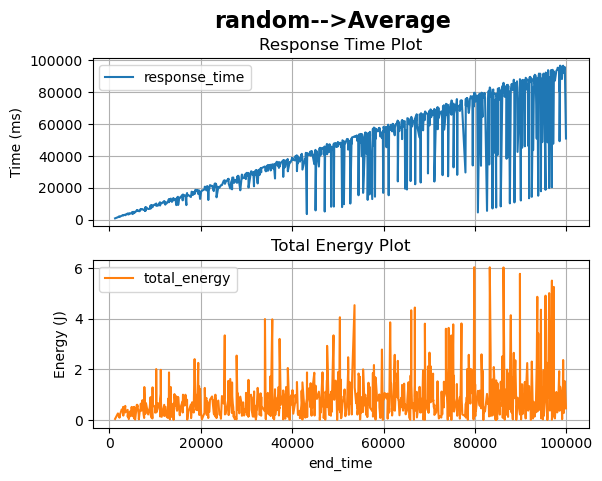

In [8]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1313               1312                112            1200               0.0   
2001               2000                  0            2000               0.2   
2113               2012                 84             800               0.0   
2223               2122                122            2000               0.0   
2301               2000                  0            2000               0.2   
...                 ...                ...             ...               ...   
99001             95200                  0            8000               0.8   
99294             94293               3299             600               0.0   
99746             53045               2577            1400               0.0   
99836             94035               2143            1800               0.0   
99950         

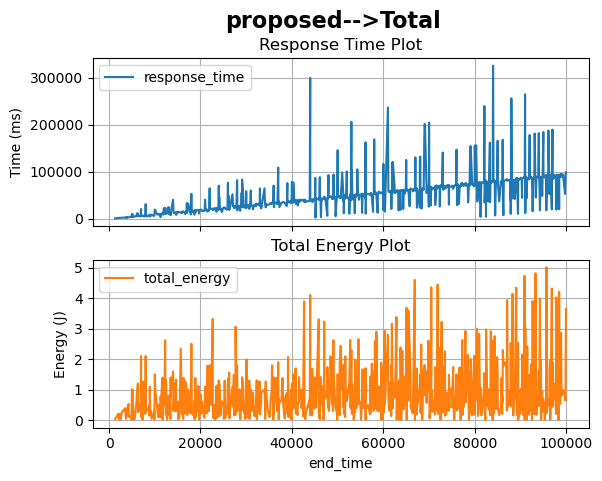

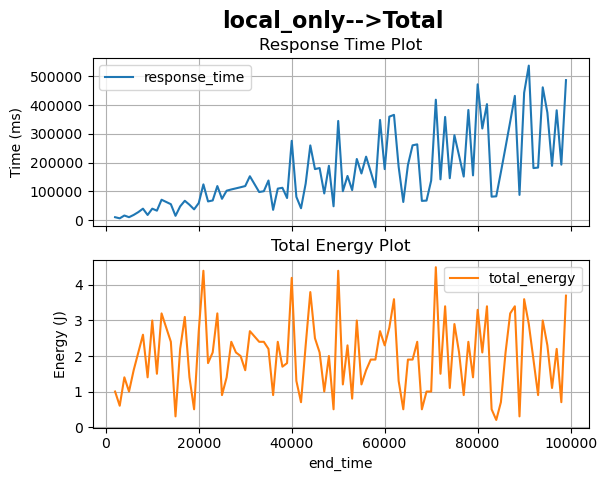

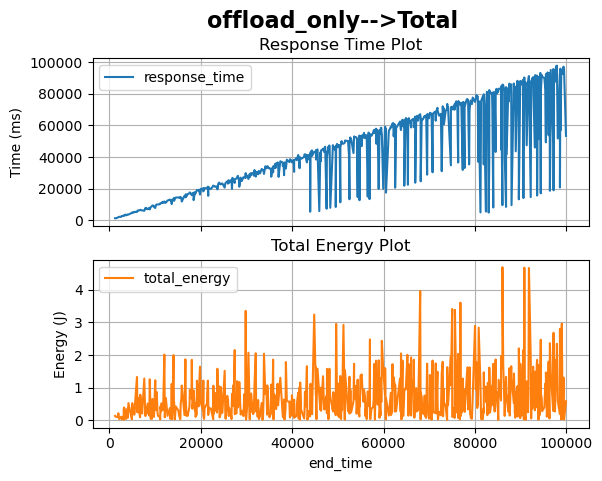

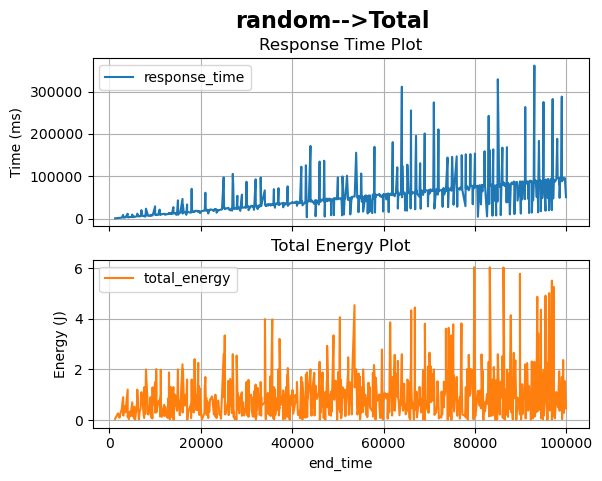

In [9]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")